In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Problems and measurement protocol from your assignment
# ============================================================

N_VALUES = (15, 31, 63, 127, 255, 511)

PROBLEMS = {
    "P0": {
        "u": lambda x: x * (1 - x),
        "f": lambda x: np.full_like(x, 2.0),
        "M4": 0.0,
        "label": r"$u(x)=x(1-x)$",
    },
    "P1": {
        "u": lambda x: x**4 - x,
        "f": lambda x: -12 * x**2,
        "M4": 24.0,
        "label": r"$u(x)=x^4-x$",
    },
    "P2": {
        "u": lambda x: np.expm1(x) - np.expm1(1.0) * x,
        "f": lambda x: -np.exp(x),
        "M4": np.e,
        "label": r"$u(x)=e^x-1-(e-1)x$",
    },
    "P3": {
        "u": lambda x: np.abs(x - 0.5)**3 - 1 / 8,
        "f": lambda x: -6 * np.abs(x - 0.5),
        "M4": None,  # T1 does not apply
        "label": r"$u(x)=|x-1/2|^3-1/8$",
    },
}


# ============================================================
# 2. Solver
# ============================================================

def solve_poisson(f, N):
    """
    Solve -u''(x) = f(x) on [0, 1], with u(0) = u(1) = 0.

    Three-point scheme:
        (-U[j-1] + 2*U[j] - U[j+1]) / h**2 = f(x[j])

    Parameters
    ----------
    f : callable
        Accepts an array of interior coordinates.
        Returns a scalar or an array of forcing values.
    N : int
        Number of INTERIOR nodes.

    Returns
    -------
    x : ndarray, shape (N+2,)
        All grid coordinates, including endpoints.
    U : ndarray, shape (N+2,)
        Numerical solution, including zero boundary values.

    Uses Thomas elimination: O(N) time and memory.
    """
    if isinstance(N, bool) or not isinstance(N, (int, np.integer)) or N < 1:
        raise ValueError("N must be a positive integer.")

    h = 1.0 / (N + 1)
    x = np.arange(N + 2) * h

    # Multiply the equation by h²:
    # tridiag(-1, 2, -1) U = h² f
    rhs = np.broadcast_to(
        np.asarray(f(x[1:-1]), dtype=float), (N,)
    ).copy() * h**2

    if not np.all(np.isfinite(rhs)):
        raise ValueError("The forcing must be finite at all interior nodes.")

    diagonal = np.full(N, 2.0)

    # Forward elimination
    for j in range(1, N):
        factor = -1.0 / diagonal[j - 1]
        diagonal[j] += factor
        rhs[j] -= factor * rhs[j - 1]

    # Back substitution; endpoints remain zero
    U = np.zeros(N + 2)
    U[N] = rhs[-1] / diagonal[-1]

    for j in range(N - 2, -1, -1):
        U[j + 1] = (rhs[j] + U[j + 2]) / diagonal[j]

    return x, U


# ============================================================
# 3. Separate metric functions
# ============================================================

def maximum_error(u_exact, U):
    """Maximum absolute nodal error, including endpoints."""
    u_exact = np.asarray(u_exact)
    U = np.asarray(U)

    if u_exact.shape != U.shape:
        raise ValueError("Exact and numerical values must have matching shapes.")

    return float(np.max(np.abs(u_exact - U)))


def observed_order(E_coarse, E_fine, *, defined=True):
    """
    Observed order when h is halved:
        p = log2(E_coarse / E_fine)

    Use defined=False for P0.
    """
    if (
        not defined
        or not np.isfinite(E_coarse)
        or not np.isfinite(E_fine)
        or E_coarse <= 0
        or E_fine <= 0
    ):
        return np.nan

    return float(np.log2(E_coarse / E_fine))


def t1_bound(h, M4):
    """
    T1 bound: E(h) <= M4*h²/96.
    Returns NaN when T1 does not apply.
    """
    if M4 is None:
        return np.nan

    return float(M4 * h**2 / 96)


def algebraic_residual(U, f_values, h):
    """Maximum absolute residual of the original equation: ||A_h U - f||∞."""
    U = np.asarray(U)
    discrete_operator = (-U[:-2] + 2 * U[1:-1] - U[2:]) / h**2

    return float(np.max(np.abs(discrete_operator - f_values)))


def scaled_error(E, h):
    """E(h)/h²: useful for checking second-order behavior."""
    return float(E / h**2)


def bound_ratio(E, bound):
    """E/T1_bound; undefined for a zero or inapplicable bound."""
    if not np.isfinite(bound) or bound <= 0:
        return np.nan

    return float(E / bound)


# ============================================================
# 4. Run the measurement protocol
# ============================================================

def run_measurement_protocol():
    """
    Evaluate P0–P3 for N = 15, 31, 63, 127, 255, 511.

    The observed order is stored on the FINER grid's row.
    P0 has no assigned order.
    P3's separate prediction is not treated as a T1 bound.

    Returns a list of dictionaries, suitable for pandas.DataFrame.
    """
    rows = []

    for name, problem in PROBLEMS.items():
        previous_error = None

        for N in N_VALUES:
            h = 1.0 / (N + 1)
            x, U = solve_poisson(problem["f"], N)

            E = maximum_error(problem["u"](x), U)
            bound = t1_bound(h, problem["M4"])
            residual = algebraic_residual(
                U, problem["f"](x[1:-1]), h
            )

            p = (
                np.nan
                if previous_error is None
                else observed_order(
                    previous_error, E, defined=(name != "P0")
                )
            )

            rows.append({
                "Problem": name,
                "N": N,
                "h": h,
                "E_max": E,
                "p_obs": p,
                "T1_bound": bound,
                "E_over_h2": scaled_error(E, h),
                "E_over_T1_bound": bound_ratio(E, bound),
                "Residual_inf": residual,
                "P3_separate_prediction": h**2 / 2 if name == "P3" else np.nan,
            })

            previous_error = E

    return rows


# ============================================================
# 5. Visualize the three-point stencil
# ============================================================

def plot_three_point_stencil():
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.set_xlim(-1.6, 1.6)
    ax.set_ylim(-1.1, 1.1)
    ax.axis("off")

    ax.set_title(
        "Three-point approximation of the second derivative",
        fontsize=16,
        pad=15,
    )

    ax.plot([-1.3, 1.3], [0.5, 0.5], color="lightgray", lw=3)

    for position, coordinate, weight in zip(
        [-1, 0, 1],
        [r"$x_{j-1}$", r"$x_j$", r"$x_{j+1}$"],
        ["−1", "+2", "−1"],
    ):
        ax.scatter(position, 0.5, s=1000, color="#287b8e", zorder=3)
        ax.text(
            position, 0.5, weight,
            ha="center", va="center", color="white", fontsize=18,
        )
        ax.text(position, 0.85, coordinate, ha="center", fontsize=17)

    for left, right in [(-1, 0), (0, 1)]:
        ax.annotate(
            "",
            xy=(left, 0.08),
            xytext=(right, 0.08),
            arrowprops={"arrowstyle": "<->", "color": "#405a78"},
        )
        ax.text((left + right) / 2, -0.12, r"$h$", ha="center", fontsize=16)

    ax.text(
        0, -0.5,
        r"$\frac{-U_{j-1}+2U_j-U_{j+1}}{h^2}=f(x_j)$",
        ha="center", fontsize=23,
    )

    ax.text(
        0, -0.95,
        r"$h=\frac{1}{N+1},\qquad U_0=U_{N+1}=0$",
        ha="center", fontsize=17,
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 6. Plot exact/numerical solutions and signed errors
# ============================================================

def plot_solutions_and_errors(N=15):
    colors = ["#3274a1", "#df8642", "#288b78", "#8b5eb5"]
    x_dense = np.linspace(0, 1, 1001)

    fig, axes = plt.subplots(
        2, 4, figsize=(17, 7), constrained_layout=True
    )

    for column, ((name, problem), color) in enumerate(
        zip(PROBLEMS.items(), colors)
    ):
        x, U = solve_poisson(problem["f"], N)
        exact = problem["u"](x)

        ax = axes[0, column]
        ax.plot(
            x_dense, problem["u"](x_dense),
            color=color, lw=2, label="Exact",
        )
        ax.plot(
            x, U, "o",
            color="#243746", mfc="white", ms=4, label="Numerical",
        )
        ax.set_title(f"{name}: {problem['label']}")
        ax.set_ylabel("Solution")
        ax.legend()

        ax = axes[1, column]
        ax.plot(x, exact - U, "o-", color=color, ms=4)
        ax.set_ylabel(r"$u(x_j)-U_j$")
        ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
        ax.set_title(
            "Round-off only" if name == "P0" else "Signed nodal error"
        )

    for ax in axes.flat:
        ax.set_xlabel("x")
        ax.grid(alpha=0.2)

    fig.suptitle(
        f"Exact and numerical solutions | N = {N} interior nodes",
        fontsize=17,
    )
    plt.show()


# ============================================================
# 7. Plot convergence and observed orders
# ============================================================

def plot_convergence(rows):
    from matplotlib.ticker import NullLocator

    colors = {
        "P0": "#3274a1",
        "P1": "#df8642",
        "P2": "#288b78",
        "P3": "#8b5eb5",
    }

    fig, axes = plt.subplots(
        1, 3, figsize=(16, 4.8), constrained_layout=True
    )

    for name in PROBLEMS:
        selected = [row for row in rows if row["Problem"] == name]

        h = np.array([row["h"] for row in selected])
        E = np.array([row["E_max"] for row in selected])
        p = np.array([row["p_obs"] for row in selected])

        if name == "P0":
            # Zero error cannot be displayed on a logarithmic axis.
            positive = E > 0
            axes[2].loglog(
                h[positive], E[positive], "o-",
                color=colors[name], label="P0 numerical error",
            )
            continue

        axes[0].loglog(
            h, E, "o-", color=colors[name], label=f"{name}: measured"
        )

        if name == "P3":
            prediction = h**2 / 2
            label = "P3: separate formula"
        else:
            prediction = np.array([row["T1_bound"] for row in selected])
            label = f"{name}: T1 bound"

        axes[0].loglog(
            h, prediction, "--",
            color=colors[name], alpha=0.7, label=label,
        )

        axes[1].semilogx(
            h[1:], p[1:], "o-", color=colors[name], label=name
        )

    axes[1].axhline(
        2, color="gray", linestyle=":", label="Predicted order 2"
    )

    titles = [
        "Maximum error and predictions",
        "Observed convergence order",
        "P0: round-off-sized errors",
    ]
    ylabels = [r"$E(h)$", r"$p_{\mathrm{obs}}$", r"$E(h)$"]

    for ax, title, ylabel in zip(axes, titles, ylabels):
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.set_xlabel("h — refinement to the right")
        ax.set_xticks(
            [1 / 16, 1 / 64, 1 / 256],
            labels=["1/16", "1/64", "1/256"],
        )
        ax.xaxis.set_minor_locator(NullLocator())
        ax.invert_xaxis()
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8)

    plt.show()

,Problem,N,h,E_max,p_obs,T1_bound,E_over_h2,E_over_T1_bound,Residual_inf,P3_separate_prediction
0,P0,15,0.062500,2.775558e-17,—,0.000000e+00,0.000000,—,2.132e-14,—
1,P0,31,0.031250,7.771561e-16,—,0.000000e+00,0.000000,—,5.684e-14,—
2,P0,63,0.015625,2.386980e-15,—,0.000000e+00,0.000000,—,2.274e-13,—
3,P0,127,0.007812,2.386980e-15,—,0.000000e+00,0.000000,—,1.364e-12,—
4,P0,255,0.003906,8.881784e-15,—,0.000000e+00,0.000000,—,3.638e-12,—
5,P0,511,0.001953,1.987299e-14,—,0.000000e+00,0.000000,—,2.183e-11,—
6,P1,15,0.062500,9.765625e-04,—,9.765625e-04,0.250000,1.000000,4.263e-14,—
7,P1,31,0.031250,2.441406e-04,2.000000,2.441406e-04,0.250000,1.000000,5.684e-14,—
8,P1,63,0.015625,6.103516e-05,2.000000,6.103516e-05,0.250000,1.000000,4.547e-13,—
9,P1,127,0.007812,1.525879e-05,2.000000,1.525879e-05,0.250000,1.000000,1.819e-12,—


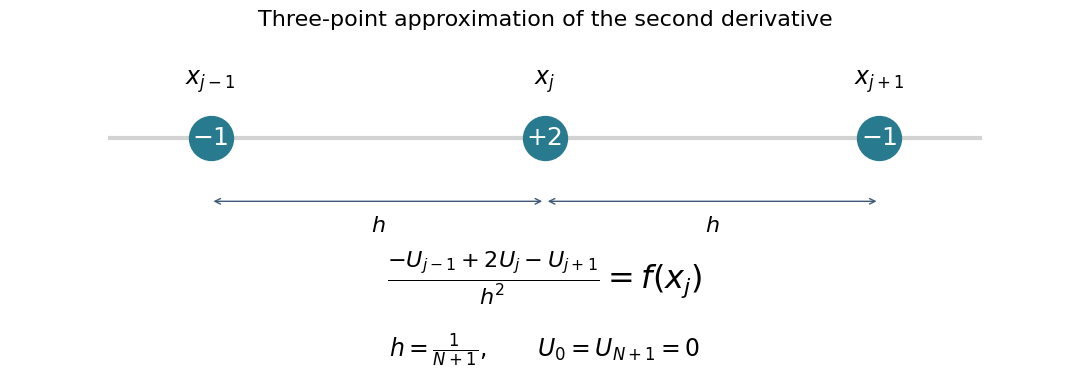

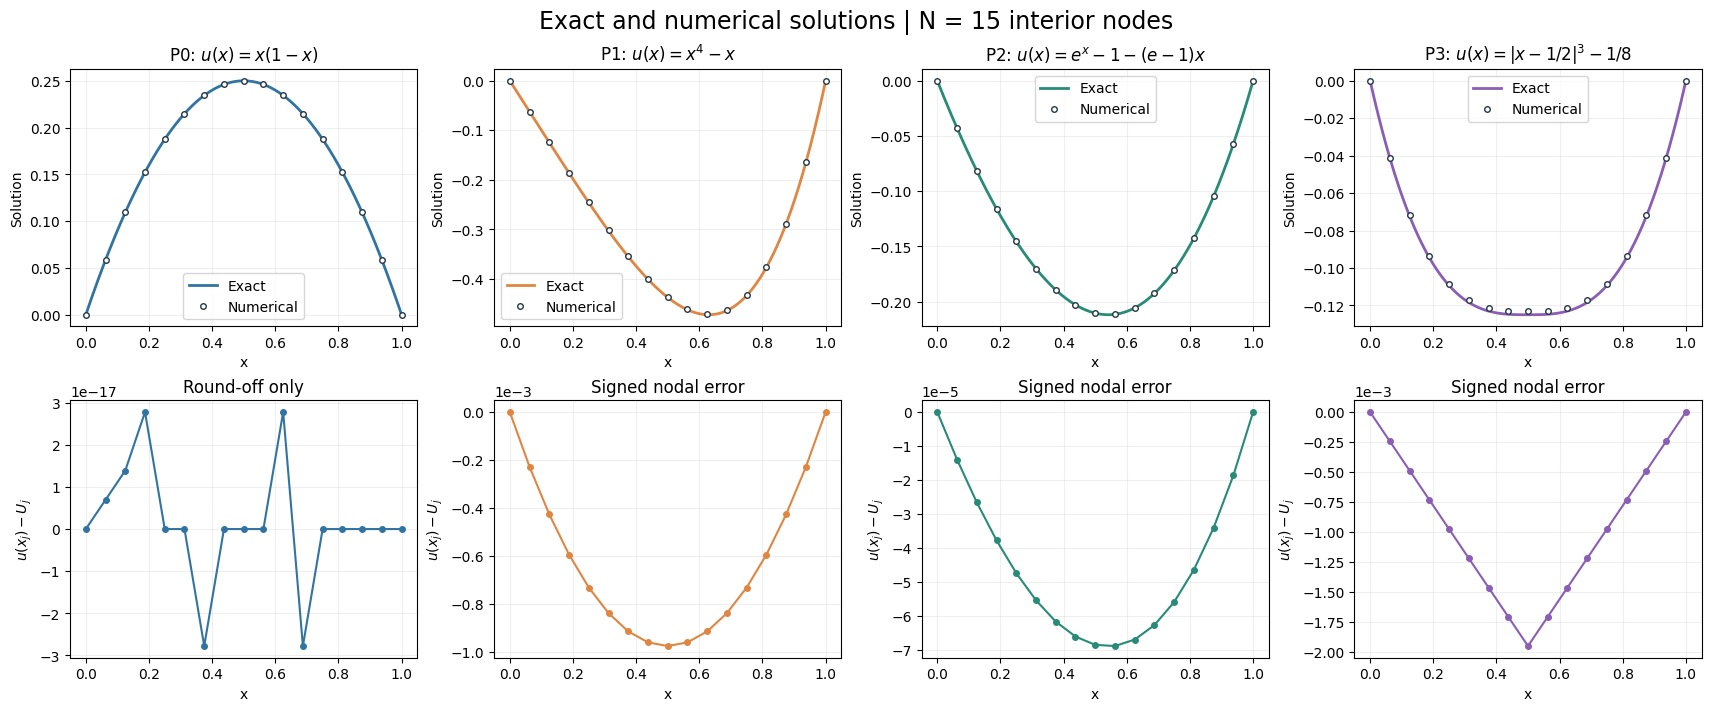

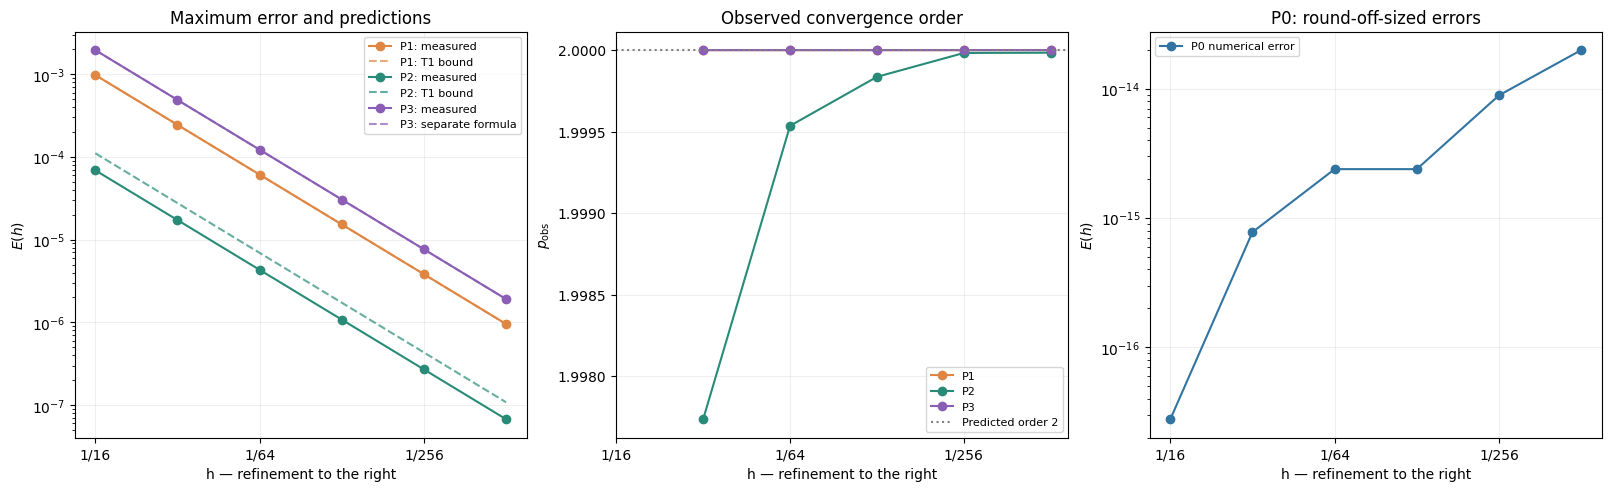

In [3]:
import pandas as pd

results = run_measurement_protocol()
df = pd.DataFrame(results)

display(
    df.style.format({
        "h": "{:.6f}",
        "E_max": "{:.6e}",
        "p_obs": "{:.6f}",
        "T1_bound": "{:.6e}",
        "E_over_h2": "{:.6f}",
        "E_over_T1_bound": "{:.6f}",
        "Residual_inf": "{:.3e}",
        "P3_separate_prediction": "{:.6e}",
    }, na_rep="—")
)

plot_three_point_stencil()
plot_solutions_and_errors(N=15)
plot_convergence(results)

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.legendre import leggauss


# ============================================================
# 1. Same problems and grids
# ============================================================

FEM_N_VALUES = (15, 31, 63, 127, 255, 511)

FEM_PROBLEMS = {
    "P0": {
        "u": lambda x: x * (1 - x),
        "du": lambda x: 1 - 2*x,
        "f": lambda x: np.full_like(x, 2.0),
        "M2": 2.0,
        "label": r"$u=x(1-x)$",
    },
    "P1": {
        "u": lambda x: x**4 - x,
        "du": lambda x: 4*x**3 - 1,
        "f": lambda x: -12*x**2,
        "M2": 12.0,
        "label": r"$u=x^4-x$",
    },
    "P2": {
        "u": lambda x: np.expm1(x) - np.expm1(1.0)*x,
        "du": lambda x: np.exp(x) - np.expm1(1.0),
        "f": lambda x: -np.exp(x),
        "M2": np.e,
        "label": r"$u=e^x-1-(e-1)x$",
    },
    "P3": {
        "u": lambda x: np.abs(x - 0.5)**3 - 1/8,
        "du": lambda x: 3*(x - 0.5)*np.abs(x - 0.5),
        "f": lambda x: -6*np.abs(x - 0.5),
        "M2": 3.0,
        "label": r"$u=|x-1/2|^3-1/8$",
    },
}


# ============================================================
# 2. One FEM solver: assembly and solution
# ============================================================

def solve_fem(f, N, quadrature_order=5):
    """
    Linear FEM for -u'' = f on [0,1], with u(0)=u(1)=0.

    N = number of interior nodes.
    N+1 = number of elements.

    Returns
    -------
    x : all node coordinates, shape (N+2,)
    U : FEM nodal coefficients, shape (N+2,)
    system : assembled interior stiffness diagonals and load vector

    Uses Gauss-Legendre load quadrature and an O(N)
    tridiagonal solve.
    """
    if isinstance(N, bool) or not isinstance(N, (int, np.integer)) or N < 1:
        raise ValueError("N must be a positive integer.")

    if (
        isinstance(quadrature_order, bool)
        or not isinstance(quadrature_order, (int, np.integer))
        or quadrature_order < 1
    ):
        raise ValueError("quadrature_order must be a positive integer.")

    x = np.linspace(0.0, 1.0, N + 2)
    lengths = np.diff(x)

    # Reference element: xi in [-1,1]
    xi, weights = leggauss(quadrature_order)
    phi_left = (1 - xi) / 2
    phi_right = (1 + xi) / 2

    # Quadrature coordinates on every physical element
    xq = (
        x[:-1, None]
        + lengths[:, None] * (xi[None, :] + 1) / 2
    )

    fq = np.broadcast_to(
        np.asarray(f(xq), dtype=float), xq.shape
    )

    if not np.all(np.isfinite(fq)):
        raise ValueError("Forcing must be finite at quadrature points.")

    # Element load vectors
    load_left = lengths / 2 * np.sum(
        fq * (weights * phi_left)[None, :], axis=1
    )
    load_right = lengths / 2 * np.sum(
        fq * (weights * phi_right)[None, :], axis=1
    )

    # Assemble full load vector
    full_load = np.zeros(N + 2)
    full_load[:-1] += load_left
    full_load[1:] += load_right

    # Assemble interior stiffness matrix as three diagonals
    diagonal = 1 / lengths[:-1] + 1 / lengths[1:]
    off_diagonal = -1 / lengths[1:-1]
    load = full_load[1:-1].copy()

    # Preserve assembled system for residual evaluation
    system = {
        "diagonal": diagonal.copy(),
        "off_diagonal": off_diagonal.copy(),
        "load": load.copy(),
    }

    # Thomas elimination
    d = diagonal.copy()
    rhs = load.copy()

    for j in range(1, N):
        factor = off_diagonal[j - 1] / d[j - 1]
        d[j] -= factor * off_diagonal[j - 1]
        rhs[j] -= factor * rhs[j - 1]

    U = np.zeros(N + 2)
    U[N] = rhs[-1] / d[-1]

    for j in range(N - 2, -1, -1):
        U[j + 1] = (
            rhs[j] - off_diagonal[j] * U[j + 2]
        ) / d[j]

    return x, U, system


# ============================================================
# 3. Separate metric functions
# ============================================================

def fem_nodal_error(u, x, U):
    """Maximum error at the mesh nodes."""
    return float(np.max(np.abs(u(x) - U)))


def fem_maximum_error(u, x, U, samples_per_element=101):
    """
    Sampled estimate of the full-domain maximum error.

    This is NOT only a nodal error.
    Increase samples_per_element to check sampling sensitivity.
    """
    if samples_per_element < 2:
        raise ValueError("Use at least two samples per element.")

    t = np.linspace(0, 1, samples_per_element)

    xs = (
        x[:-1, None]
        + np.diff(x)[:, None] * t[None, :]
    )
    uh = (
        U[:-1, None] * (1 - t)[None, :]
        + U[1:, None] * t[None, :]
    )

    return float(np.max(np.abs(u(xs) - uh)))


def fem_l2_error(u, x, U, quadrature_order=8):
    """sqrt(integral_0^1 (u-u_h)^2 dx), evaluated by quadrature."""
    xi, weights = leggauss(quadrature_order)
    t = (xi + 1) / 2
    lengths = np.diff(x)

    xq = x[:-1, None] + lengths[:, None] * t[None, :]
    uh = (
        U[:-1, None] * (1 - t)[None, :]
        + U[1:, None] * t[None, :]
    )

    squared_error = (u(xq) - uh)**2

    integral = np.sum(
        lengths[:, None] / 2
        * weights[None, :]
        * squared_error
    )

    return float(np.sqrt(integral))


def fem_h1_seminorm_error(du, x, U, quadrature_order=8):
    """sqrt(integral_0^1 (u'-u_h')^2 dx)."""
    xi, weights = leggauss(quadrature_order)
    lengths = np.diff(x)

    xq = (
        x[:-1, None]
        + lengths[:, None] * (xi[None, :] + 1) / 2
    )

    # Derivative of a linear element is constant within it
    slopes = np.diff(U) / lengths
    squared_error = (du(xq) - slopes[:, None])**2

    integral = np.sum(
        lengths[:, None] / 2
        * weights[None, :]
        * squared_error
    )

    return float(np.sqrt(integral))


def fem_observed_order(error_coarse, error_fine):
    """Observed order for successive grids with h halved."""
    if (
        not np.isfinite(error_coarse)
        or not np.isfinite(error_fine)
        or error_coarse <= 0
        or error_fine <= 0
    ):
        return np.nan

    return float(np.log2(error_coarse / error_fine))


def fem_interpolation_bound(h, M2):
    """
    Full-domain maximum-error bound for exactly integrated FEM
    in this 1D constant-coefficient problem.
    """
    return float(M2 * h**2 / 8)


def fem_algebraic_residual(U, system):
    """Infinity norm of the assembled FEM residual K U - F."""
    interior = U[1:-1]
    diagonal = system["diagonal"]
    off = system["off_diagonal"]

    residual = diagonal * interior - system["load"]
    residual[:-1] += off * interior[1:]
    residual[1:] += off * interior[:-1]

    return float(np.max(np.abs(residual)))


# ============================================================
# 4. Measurement protocol
# ============================================================

def run_fem_protocol(
    load_quadrature_order=5,
    error_quadrature_order=8,
    samples_per_element=101,
):
    """
    Same six grids as the assignment.

    Orders are stored on the finer grid's row.
    No convergence order is assigned to the nodal error.
    """
    rows = []

    for name, problem in FEM_PROBLEMS.items():
        previous = None

        for N in FEM_N_VALUES:
            x, U, system = solve_fem(
                problem["f"], N,
                quadrature_order=load_quadrature_order,
            )
            h = 1 / (N + 1)

            E_inf = fem_maximum_error(
                problem["u"], x, U, samples_per_element
            )
            E_l2 = fem_l2_error(
                problem["u"], x, U, error_quadrature_order
            )
            E_h1 = fem_h1_seminorm_error(
                problem["du"], x, U, error_quadrature_order
            )

            current = (E_inf, E_l2, E_h1)

            if previous is None:
                orders = (np.nan, np.nan, np.nan)
            else:
                orders = tuple(
                    fem_observed_order(coarse, fine)
                    for coarse, fine in zip(previous, current)
                )

            bound = fem_interpolation_bound(h, problem["M2"])

            rows.append({
                "Problem": name,
                "N": N,
                "h": h,
                "E_nodal": fem_nodal_error(problem["u"], x, U),
                "E_inf_sampled": E_inf,
                "p_inf": orders[0],
                "E_L2": E_l2,
                "p_L2": orders[1],
                "E_H1_semi": E_h1,
                "p_H1": orders[2],
                "Interpolation_bound": bound,
                "E_inf_over_bound": E_inf / bound,
                "Residual_inf": fem_algebraic_residual(U, system),
            })

            previous = current

    return rows


# ============================================================
# 5. Piecewise-linear FEM scheme
# ============================================================

def plot_fem_scheme():
    x = np.linspace(0, 1, 9)
    U = x * (1 - x)
    dense = np.linspace(0, 1, 501)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(dense, dense*(1-dense), label="Exact solution", lw=2)
    axes[0].plot(x, U, "o-", label="Piecewise-linear FEM")
    axes[0].set_title("FEM connects nodal coefficients with straight lines")
    axes[0].set_ylabel("Solution")
    axes[0].legend()

    # One global hat basis function
    j = 4
    axes[1].plot(
        [x[j-1], x[j], x[j+1]],
        [0, 1, 0],
        "o-", color="#288b78", lw=2,
    )
    axes[1].axhline(0, color="gray", lw=0.8)
    axes[1].set_title(r"Hat basis function $\phi_j(x)$")
    axes[1].set_ylabel(r"$\phi_j$")
    axes[1].set_xlim(0, 1)
    axes[1].text(
        0.5, 0.45,
        r"$u_h(x)=\sum_j U_j\phi_j(x)$",
        ha="center", fontsize=15,
    )

    for ax in axes:
        ax.set_xlabel("x")
        ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()


# ============================================================
# 6. Exact/FEM solutions and errors BETWEEN nodes
# ============================================================

def plot_fem_solutions(N=15, quadrature_order=5):
    colors = ["#3274a1", "#df8642", "#288b78", "#8b5eb5"]

    fig, axes = plt.subplots(
        2, 4, figsize=(17, 7), constrained_layout=True
    )

    for column, ((name, problem), color) in enumerate(
        zip(FEM_PROBLEMS.items(), colors)
    ):
        x, U, _ = solve_fem(problem["f"], N, quadrature_order)

        # Many points per element to expose interpolation error
        t = np.linspace(0, 1, 101)
        xs = (
            x[:-1, None] + np.diff(x)[:, None]*t[None, :]
        ).ravel()

        uh = np.interp(xs, x, U)
        exact = problem["u"](xs)

        ax = axes[0, column]
        ax.plot(xs, exact, color=color, lw=2, label="Exact")
        ax.plot(
            x, U, "o--", color="#243746",
            ms=3, mfc="white", label="Linear FEM",
        )
        ax.set_title(f"{name}: {problem['label']}")
        ax.set_ylabel("Solution")
        ax.legend(fontsize=9)

        ax = axes[1, column]
        ax.plot(xs, exact - uh, color=color)
        ax.plot(
            x, problem["u"](x) - U,
            "o", color="#243746", ms=3,
        )
        ax.set_title("Error between nodes")
        ax.set_ylabel(r"$u(x)-u_h(x)$")
        ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

    for ax in axes.flat:
        ax.set_xlabel("x")
        ax.grid(alpha=0.2)

    fig.suptitle(
        f"Linear FEM | N={N} interior nodes, {N+1} elements",
        fontsize=17,
    )
    plt.show()


# ============================================================
# 7. Convergence plots
# ============================================================

def plot_fem_convergence(rows):
    from matplotlib.ticker import NullLocator

    colors = {
        "P0": "#3274a1",
        "P1": "#df8642",
        "P2": "#288b78",
        "P3": "#8b5eb5",
    }

    metrics = [
        ("E_inf_sampled", "p_inf", "Sampled maximum error", 2),
        ("E_L2", "p_L2", r"$L^2$ error", 2),
        ("E_H1_semi", "p_H1", r"$H^1$ seminorm error", 1),
    ]

    fig, axes = plt.subplots(
        2, 3, figsize=(15, 8), constrained_layout=True
    )

    for column, (error_key, order_key, title, expected) in enumerate(metrics):
        for name, color in colors.items():
            selected = [r for r in rows if r["Problem"] == name]
            h = np.array([r["h"] for r in selected])

            axes[0, column].loglog(
                h, [r[error_key] for r in selected],
                "o-", color=color, label=name,
            )

            axes[1, column].semilogx(
                h[1:], [r[order_key] for r in selected[1:]],
                "o-", color=color, label=name,
            )

        axes[0, column].set_title(title)
        axes[0, column].set_ylabel("Error")

        axes[1, column].axhline(
            expected, color="gray", linestyle=":",
            label=f"Expected order {expected}",
        )
        axes[1, column].set_ylabel("Observed order")

    for ax in axes.flat:
        ax.set_xticks(
            [1/16, 1/64, 1/256],
            labels=["1/16", "1/64", "1/256"],
        )
        ax.xaxis.set_minor_locator(NullLocator())
        ax.invert_xaxis()
        ax.set_xlabel("h — refinement to the right")
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8)

    plt.show()

,Problem,N,h,E_nodal,E_inf_sampled,p_inf,E_L2,p_L2,E_H1_semi,p_H1,Interpolation_bound,E_inf_over_bound,Residual_inf
0,P0,15,0.062500,5.551115e-17,9.765625e-04,—,7.131804e-04,—,3.608439e-02,—,9.765625e-04,1.000000,1.332268e-15
1,P0,31,0.031250,7.771561e-16,2.441406e-04,2.000000,1.782951e-04,2.000000,1.804220e-02,1.000000,2.441406e-04,1.000000,1.776357e-15
2,P0,63,0.015625,2.386980e-15,6.103516e-05,2.000000,4.457378e-05,2.000000,9.021098e-03,1.000000,6.103516e-05,1.000000,3.552714e-15
3,P0,127,0.007812,2.386980e-15,1.525879e-05,2.000000,1.114344e-05,2.000000,4.510549e-03,1.000000,1.525879e-05,1.000000,1.065814e-14
4,P0,255,0.003906,8.881784e-15,3.814697e-06,2.000000,2.785861e-06,2.000000,2.255274e-03,1.000000,3.814697e-06,1.000000,1.421085e-14
5,P0,511,0.001953,1.987299e-14,9.536743e-07,2.000000,6.964652e-07,2.000000,1.127637e-03,1.000000,9.536743e-07,1.000000,4.263256e-14
6,P1,15,0.062500,2.220446e-16,5.500004e-03,—,1.911241e-03,—,9.671953e-02,—,5.859375e-03,0.938667,1.776357e-15
7,P1,31,0.031250,1.443290e-15,1.419485e-03,1.954066,4.782646e-04,1.998629,4.839916e-02,0.998825,1.464844e-03,0.969035,1.776357e-15
8,P1,63,0.015625,3.608225e-15,3.605150e-04,1.977236,1.195945e-04,1.999657,2.420450e-02,0.999706,3.662109e-04,0.984446,7.105427e-15
9,P1,127,0.007812,4.607426e-15,9.083911e-05,1.988674,2.990041e-05,1.999914,1.210287e-02,0.999927,9.155273e-05,0.992205,1.421085e-14


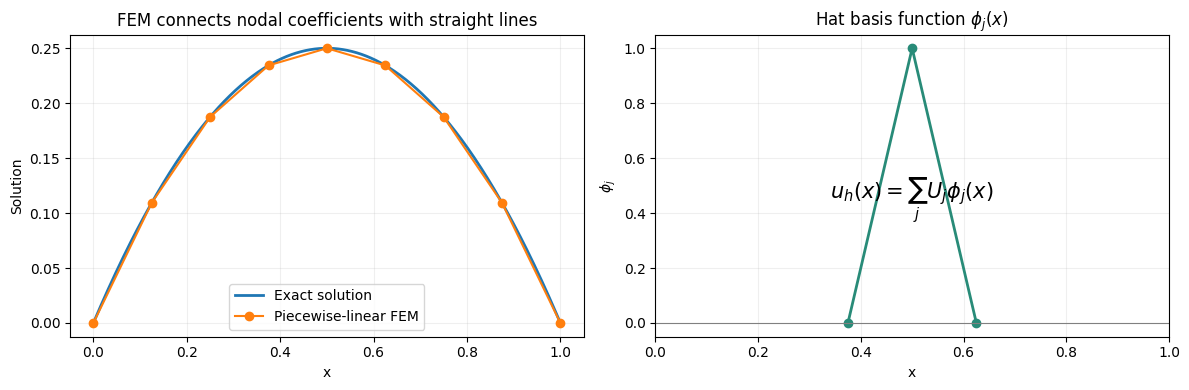

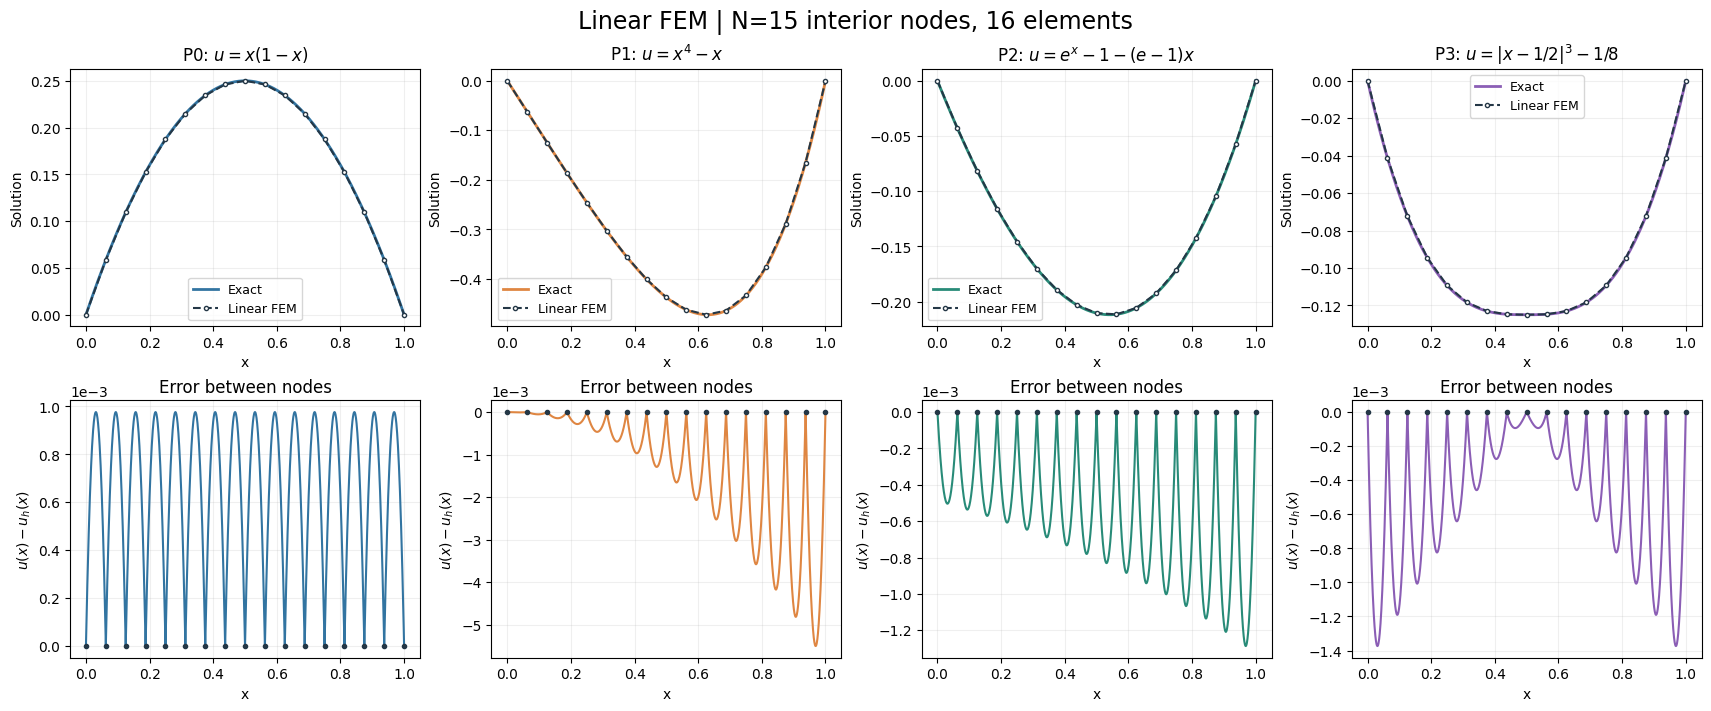

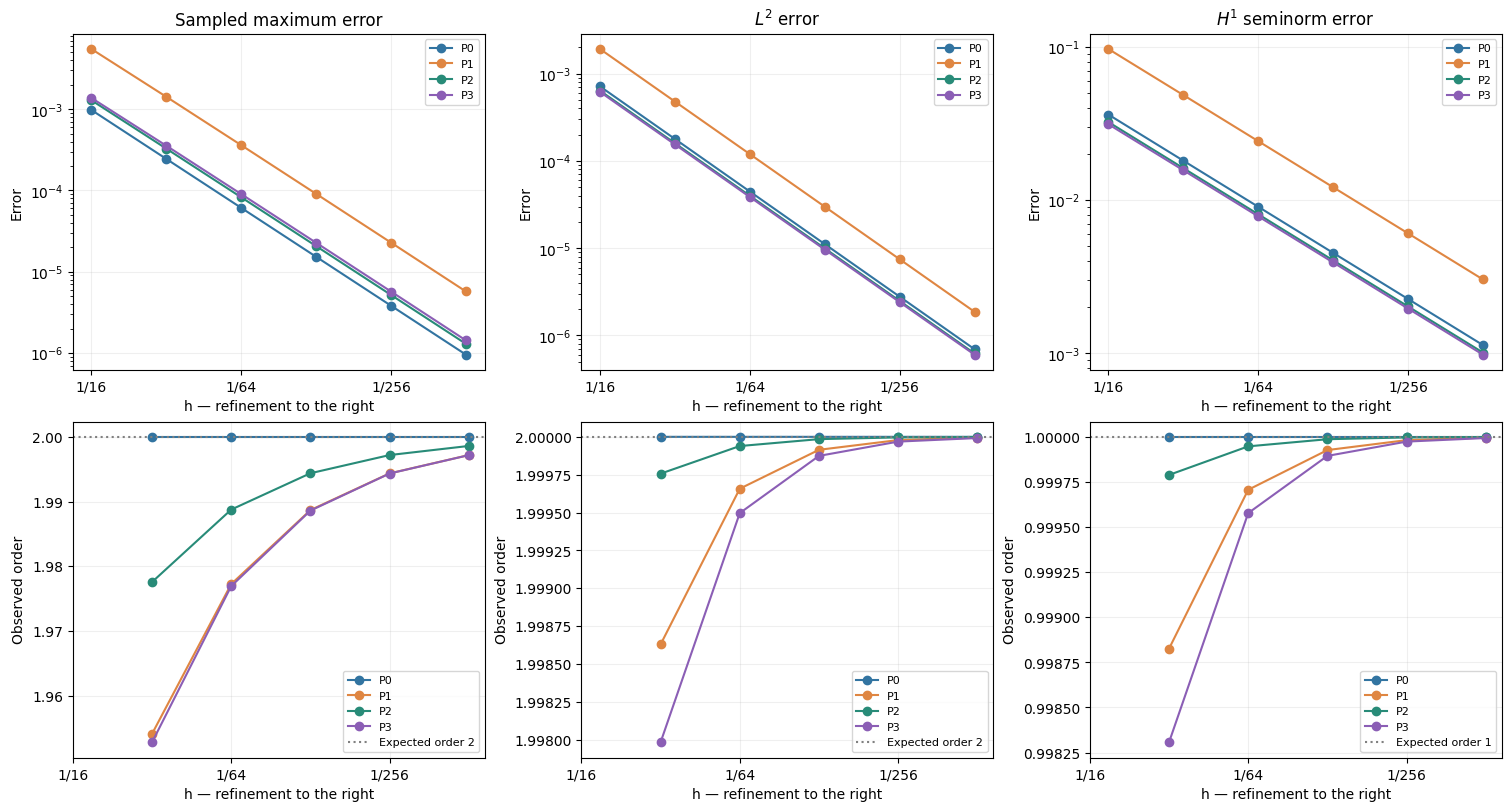

In [5]:
import pandas as pd

fem_results = run_fem_protocol()
fem_df = pd.DataFrame(fem_results)

formats = {
    column: "{:.6e}"
    for column in fem_df.columns
    if column not in ("Problem", "N")
}
formats.update({
    "h": "{:.6f}",
    "p_inf": "{:.6f}",
    "p_L2": "{:.6f}",
    "p_H1": "{:.6f}",
    "E_inf_over_bound": "{:.6f}",
})

display(fem_df.style.format(formats, na_rep="—"))

plot_fem_scheme()
plot_fem_solutions(N=15)
plot_fem_convergence(fem_results)